In [4]:
# DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML - KNN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
# Load data
train_data = pd.read_csv('src/data/training.csv')
validation_data = pd.read_csv('src/data/validation.csv')
test_data = pd.read_csv('src/data/testing.csv')
train_data.dtypes
#data.shape

id                        object
name                      object
artists                   object
danceability             float64
energy                   float64
key                        int64
loudness                 float64
speechiness              float64
liveness                 float64
tempo                    float64
duration_ms                int64
year                       int64
genre                     object
avg_artist_popularity    float64
dtype: object

In [6]:
# Not direct edit on the source dataset
df = train_data.copy()

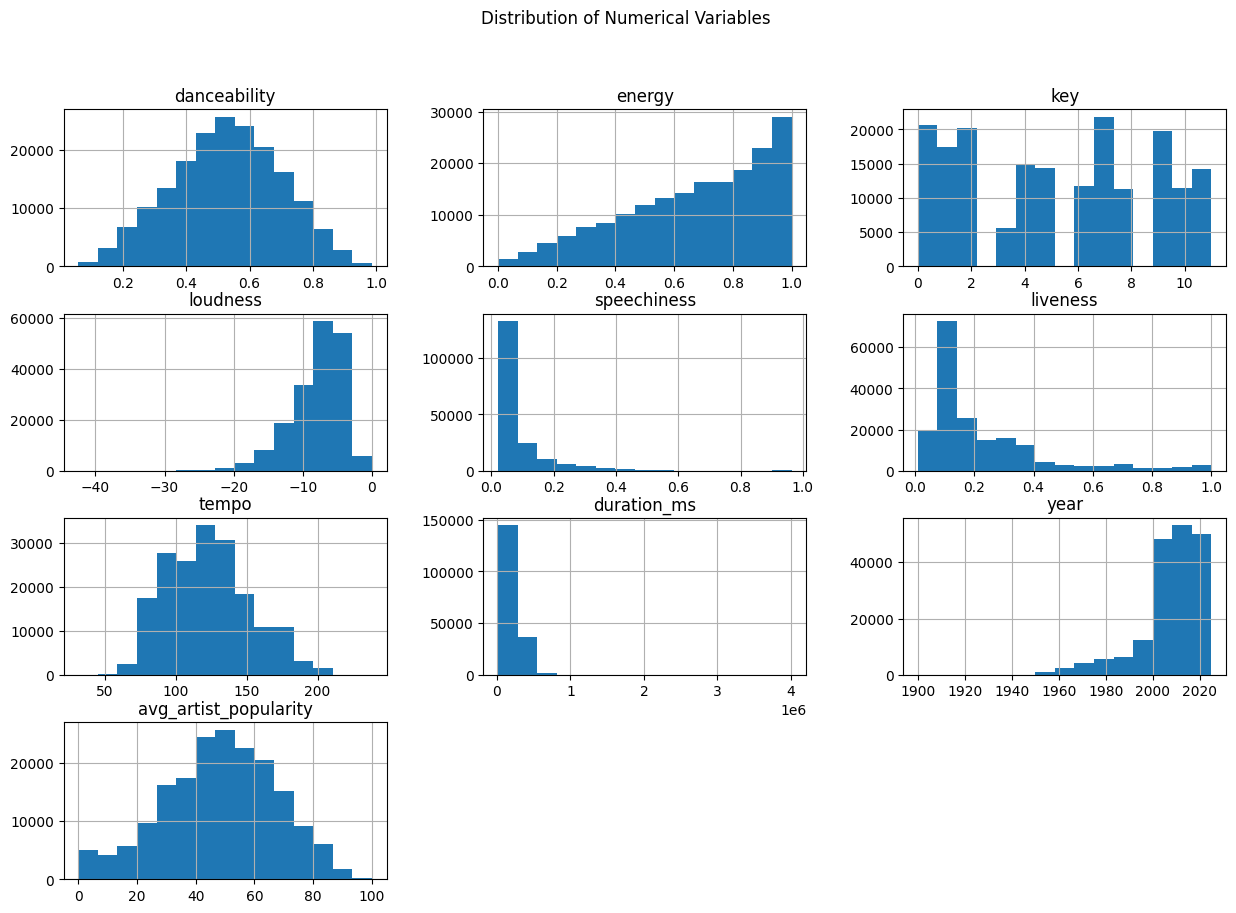


genre
Rock          65528
Pop           24166
Electronic    23192
Folk          16965
Country       15381
Hip-Hop       13874
R&B            9210
Jazz           5779
Blues          5405
Classical      4040
Name: count, dtype: int64

artists
["Elvis Presley"]      491
["Grateful Dead"]      474
["Aretha Franklin"]    396
["Bob Dylan"]          335
["Johnny Cash"]        265
Name: count, dtype: int64


In [7]:
numerical_cols = ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'liveness', 'tempo', 'duration_ms', 'year', 'avg_artist_popularity']
df[numerical_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Variables')
plt.show()

# Frequency of categorical variables
print()
print(df['genre'].value_counts())

# Top 10 most frequent artists
print()
print(df['artists'].value_counts().head())

In [8]:
# Data Split
# from sklearn.model_selection import train_test_split
# #GridSearchCV

# train_data, test_data = train_test_split(df, test_size=0.25, random_state=376)
# print("Viewing training x_train", train_data.shape)
# print("Viewing test test_data", test_data.shape)

In [9]:
# Audio features used to represent the 'sound' of each track
audio_features = ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'liveness', 'tempo', 'duration_ms', 'year', 'avg_artist_popularity']

# Build track pool from TRAIN data only
track_pool = train_data.drop_duplicates(subset='id').reset_index(drop=True)

# Feature matrix: one row per unique track
track_matrix = track_pool[audio_features]

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Weight setting
feature_weights = {
    'danceability':      1.0,
    'energy':            3.0,
    'key':               0.3,
    'loudness':          1.0,
    'speechiness':       0.5,
    'liveness':          1.5,
    'tempo':             0.5,
    'duration_ms':       0.3,
    'year':              0.5,
    'avg_artist_popularity': 0.8
}

# Normalization — fit on TRAIN data only
scaler = MinMaxScaler()
track_matrix_scaled = pd.DataFrame(
    scaler.fit_transform(track_pool[audio_features]),
    columns=audio_features
)

weights = np.array([feature_weights[f] for f in audio_features])
track_matrix_weighted = track_matrix_scaled * weights

# Prepare validation set — transform
val_pool = validation_data.drop_duplicates(subset='id').reset_index(drop=True)
val_matrix_scaled = pd.DataFrame(
    scaler.transform(val_pool[audio_features]),
    columns=audio_features
)
val_matrix_weighted = val_matrix_scaled * weights

# Prepare test set — transform
test_pool = test_data.drop_duplicates(subset='id').reset_index(drop=True)
test_matrix_scaled = pd.DataFrame(
    scaler.transform(test_pool[audio_features]),
    columns=audio_features
)
test_matrix_weighted = test_matrix_scaled * weights

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: in

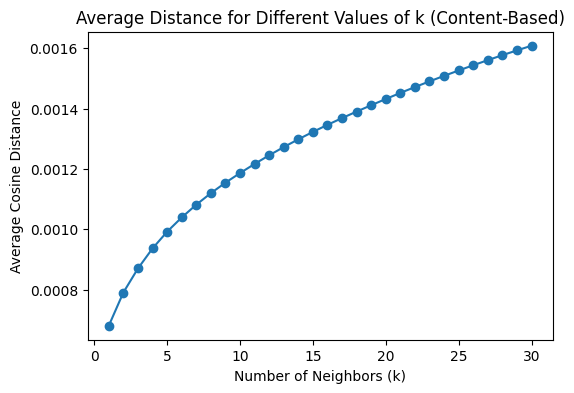

Suggested value of k: 29


In [11]:
# Discover K value using VALIDATION data
from sklearn.neighbors import NearestNeighbors

# K Value Range
k_values = list(range(1, 31))
mean_distances = []

# Find the best k — fit on train, evaluate distance on validation
for k in k_values:
    model = NearestNeighbors(n_neighbors=k, metric='cosine')
    model.fit(track_matrix_weighted)

    # Sample from VALIDATION set (not train) to avoid overfitting k
    sample = val_matrix_weighted.sample(n=min(500, len(val_matrix_weighted)), random_state=376)
    distances, indices = model.kneighbors(sample)

    # Calculate the average distance to the nearest neighbors
    mean_distance = np.mean(distances)
    mean_distances.append(mean_distance)

# Plotting the average distance metric for different values of k
plt.figure(figsize=(6, 4))
plt.plot(k_values, mean_distances, marker='o')
plt.title('Average Distance for Different Values of k (Content-Based)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Cosine Distance')
plt.show()

# Find the best k - elbow point where distance stops dropping sharply
best_k = k_values[np.argmin(np.diff(mean_distances))]
print(f"Suggested value of k: {best_k}")

In [12]:
user_tracks = track_pool[track_pool['id'].isin(user_track_ids)]
print("User Input Songs:")
print(user_tracks[['name', 'artists', 'genre', 'avg_artist_popularity']].to_string(index=False))

if user_tracks.empty:
    raise ValueError("No matching tracks found in dataset.")

# ── Query KNN per input song (instead of averaging into one profile) ───────────
# Averaging diverse genres creates a meaningless centroid — querying per song
# preserves each track's individual character and pools the results
all_candidates = []

for _, track in user_tracks.iterrows():
    track_vec = pd.DataFrame(
        scaler.transform(track[audio_features].values.reshape(1, -1)),
        columns=audio_features
    )
    track_weighted = (track_vec * weights).values

    dists, idxs = model.kneighbors(track_weighted)

    cands = track_pool.iloc[idxs[0]].copy()
    cands['cosine_sim'] = 1 - dists[0]
    all_candidates.append(cands)

# Pool all candidates — if a song appears multiple times keep its best score
candidates = (
    pd.concat(all_candidates)
    .sort_values('cosine_sim', ascending=False)
    .drop_duplicates(subset='id')
)

# ── Re-rank: audio similarity + niche boost ───────────────────────────────────
candidates['norm_popularity'] = (
    (candidates['avg_artist_popularity'] - pop_min) / (pop_max - pop_min)
)
candidates['final_score'] = (
    alpha       * candidates['cosine_sim'] +
    (1 - alpha) * (1 - candidates['norm_popularity'])
)

# Sort, exclude input songs, keep top best_k
new_playlist = (
    candidates
    .sort_values('final_score', ascending=False)
    .loc[~candidates['id'].isin(user_track_ids)]
    .head(best_k)
)

NameError: name 'user_track_ids' is not defined

In [13]:
print(f"Recommended Playlist ({len(new_playlist)} tracks)  [alpha={alpha}]:")
print(new_playlist[['name', 'artists', 'genre', 'avg_artist_popularity', 'final_score']].to_string(index=False))

print(f"\nAvg artist popularity — input songs: {user_tracks['avg_artist_popularity'].mean():.1f}")
print(f"Avg artist popularity — recommended: {new_playlist['avg_artist_popularity'].mean():.1f}")

NameError: name 'new_playlist' is not defined

In [ ]:
# Final evaluation on TEST data — run once after all tuning is done
test_sample = test_matrix_weighted.sample(n=min(500, len(test_matrix_weighted)), random_state=376)
distances_test, _ = model.kneighbors(test_sample)
print(f"Test set avg cosine distance (k={best_k}): {np.mean(distances_test):.4f}")

Test set avg cosine distance (k=29): 0.0023


In [ ]:
# Model Evaluation: Train / Validation / Test

def evaluate_split(query_pool, query_matrix, n_queries=200, seed=376):
    """Returns genre precision, RMSE, cosine similarity, and random baseline for a split."""
    idx = np.random.default_rng(seed).choice(
        len(query_pool), size=min(n_queries, len(query_pool)), replace=False
    )
    queries  = query_pool.iloc[idx].reset_index(drop=True)
    q_matrix = query_matrix.iloc[idx].reset_index(drop=True)

    genre_precisions        = []
    rmse_scores             = []
    cosine_sims             = []
    random_genre_precisions = []

    for i in range(len(queries)):
        query_vec   = q_matrix.iloc[[i]]
        query_genre = queries.iloc[i]['genre']

        dists, rec_indices = model.kneighbors(query_vec)
        recs = track_pool.iloc[rec_indices[0]]

        genre_precisions.append((recs['genre'] == query_genre).mean())
        cosine_sims.append(1 - np.mean(dists))

        rec_centroid = track_matrix_weighted.iloc[rec_indices[0]].mean().values
        rmse = np.sqrt(((query_vec.values[0] - rec_centroid) ** 2).mean())
        rmse_scores.append(rmse)

        random_recs = track_pool.sample(n=best_k, random_state=i)
        random_genre_precisions.append((random_recs['genre'] == query_genre).mean())

    return {
        'genre_precision':  np.mean(genre_precisions),
        'rmse':             np.mean(rmse_scores),
        'cosine_sim':       np.mean(cosine_sims),
        'random_precision': np.mean(random_genre_precisions),
    }

# Train queries come from track_pool — re-transform so evaluation is consistent
train_eval_matrix = pd.DataFrame(
    scaler.transform(track_pool[audio_features]), columns=audio_features
) * weights

splits = {
    'Train':      (track_pool,  train_eval_matrix),
    'Validation': (val_pool,    val_matrix_weighted),
    'Test':       (test_pool,   test_matrix_weighted),
}

results = {name: evaluate_split(pool, matrix) for name, (pool, matrix) in splits.items()}

# table
col_w = 13
header = f"{'Metric':<30}" + "".join(f"{name:>{col_w}}" for name in results)
print(header)
print("─" * len(header))

metrics = [
    ('genre_precision',  f'Genre Precision@{best_k}'),
    ('rmse',             'Avg RMSE (feature space)'),
    ('cosine_sim',       'Avg Cosine Similarity'),
    ('random_precision', 'Random Baseline Precision'),
]
for key, label in metrics:
    row = f"{label:<30}" + "".join(f"{results[s][key]:>{col_w}.4f}" for s in results)
    print(row)

print("─" * len(header))
lift_row = f"{'Lift over random':<30}"
for s in results:
    lift = results[s]['genre_precision'] / results[s]['random_precision']
    lift_row += f"{lift:>{col_w-1}.2f}x"
print(lift_row)

NameError: name 'pd' is not defined

In [ ]:
Peter_eng = ['7qiZfU4dY1lWllzX7mPBI3',
           '66qlqxhEMpSHOzjRK4il0b',
           '1Vs6quoW1jxIb4HLlgVzO5',
           '3bNv3VuUOKgrf5hu3YcuRo',
           '0DuWDLjriRPjDRoPgaCslY',
           '0ClPIeT6MSgfSgQ9ZrJbAq',
           '4B1cHpLjzKUSm7LYGmxInZ',
           '3rXH3lBfuQVG9qwpANKWHt',
           '0tgVpDi06FyKpA1z0VMD4v',
           '7n2G21wCsM4OkuEAirxKId',
            ]

Peter_korjpn = ['5vCuawHQ8Poch1odz9JDpB',
              '5IN9W6eUfk3014My9awagX',
              '3t723PlEADna6GjgquoMRW',
              '1IX47gefluXmKX4PrTBCRM',
              '0RDqNCRBGrSegk16Avfzuq',
              '0O9OnWm3z2B2TjvE051AMV',
              '3Hz3tTQwOdM6XkA0ALB2G9',
              '3pqgVtpnQbBAZoWT4AEm1B',
              '4pspYVQGFHLPEFgQPD1J7e',
              '67D4iZjmueDoQR9M1SWHw5',
             ]